#### Project Overview:
**- Task:** predict a number of a handwritten image

**- Train dataset:** MNIST: http://yann.lecun.com/exdb/mnist/ (train: 60k samples, test: 10k samples)

**- Feature types:** 28x28 pixels

**- Output:** predicted number

**- Pipeline:**\
(1) data setup and preprocessing\
(2) data analysis\
(3) train the DNN model\
(4) evaluate the model

In [200]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import pytorch_lightning as pl
import torchvision
from torchvision.datasets import MNIST
from torchmetrics import Accuracy

from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

##### 1. Data setup and preprocessing

In [201]:
class MnistDataset(pl.LightningDataModule):
    def __init__(self, data_path:str = './data'):
        super().__init__()
        self.data_path = data_path
        self.transform = transforms.Compose([transforms.ToTensor()])

    def prepare_data(self):
        MNIST(
            root=self.data_path,
            download=True
        )

    def setup(self, stage=None):
        mnist_all = MNIST(
            root=self.data_path,
            download=False,
            transform=self.transform,
            train=True
        )

        self.train, self.valid = random_split(mnist_all, [55000, 5000], generator=torch.Generator().manual_seed(1))
        
        self.test = MNIST(
            root=self.data_path,
            download=False,
            transform=self.transform,
            train=False
        )
    
    def train_dataloader(self, batch_size:int = 2056, num_workers:int = 4, shuffle:bool =True):
        return DataLoader(self.train, batch_size=batch_size, num_workers=num_workers, shuffle=shuffle)
    
    def val_dataloader(self, batch_size:int = 2056, num_workers:int = 4, shuffle:bool =False):
        return DataLoader(self.valid, batch_size=batch_size, num_workers=num_workers, shuffle=shuffle)
    
    def test_dataloader(self, batch_size:int = 2056, num_workers:int = 4, shuffle:bool =False):
        return DataLoader(self.test, batch_size=batch_size, num_workers=num_workers, shuffle=shuffle)


##### 2. Data Analysis

In [202]:
# get the data
dm = MnistDataset()
dm.prepare_data()
dm.setup()

train_loader = dm.train_dataloader()

subset = train_loader.dataset

In [203]:
type(subset) # Subset is a wrappter consists of 2 things: dataset (MNIST 60k) and indices (list 55k)
# train_dataset.dataset.targets

torch.utils.data.dataset.Subset

In [204]:
# check sample shape
sample = train_loader.dataset[0]
print("feature shape: ", sample[0].shape)
print("label: ", sample[1])
print("number of class: ", len(torch.unique(subset.dataset.targets[subset.indices])), 
      " - ", *torch.unique(train_loader.dataset.dataset.targets[subset.indices]).numpy())

feature shape:  torch.Size([1, 28, 28])
label:  7
number of class:  10  -  0 1 2 3 4 5 6 7 8 9


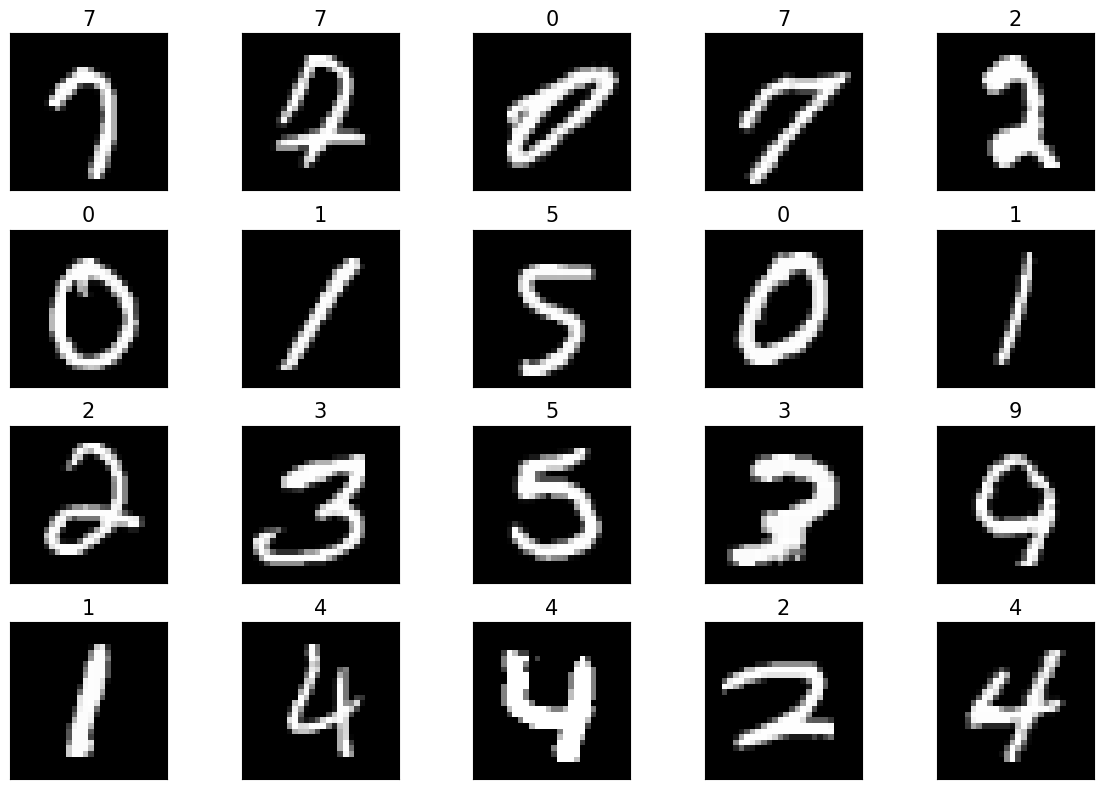

In [205]:
# visualize the image:
from itertools import islice
fig = plt.figure(figsize=(12, 8))

for i, (image, label) in islice(enumerate(subset), 20):
    ax = fig.add_subplot(4, 5, i+1)
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(label, size=15)

plt.tight_layout()
plt.show()

##### 3. Train the model

In [206]:
# create the model
class CNN_model(pl.LightningModule):
    def __init__(self, image_shape=(1, 28, 28), cnn_layers=[[32, 5, 2, 2], [64, 5, 2, 2]], 
                 fc_layers=[1024], num_class=10, p=0.3):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        
        self.model = nn.Sequential()
        self.num_class = num_class
        self.p = p
        self.fc_layers = fc_layers
        self.image_shape = image_shape
        self.cnn_layers = cnn_layers

        # tracking attributes
        self.train_acc = Accuracy(task="multiclass", num_classes=10)
        self.valid_acc = Accuracy(task="multiclass", num_classes=10)
        self.test_acc = Accuracy(task="multiclass", num_classes=10)
        
        # cnn layers
        in_channels = image_shape[0]
        for layer in range(len(self.cnn_layers)):
            layer_info = self.cnn_layers[layer]
            out_channels, kernel_size, padding, pool_kernel = layer_info[0], layer_info[1], layer_info[2], layer_info[3]
            self.model.add_module(f'conv{layer+1}', nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
            self.model.add_module(f'relu{layer+1}', nn.ReLU())
            self.model.add_module(f'pool{layer+1}', nn.MaxPool2d(kernel_size=pool_kernel))
            in_channels = out_channels

        # flatten
        self.model.add_module('flatten', nn.Flatten())
        # check flatten size
        x = torch.ones((1, 1, 28, 28))
        flatten_shape = self.model.forward(x)

        # fc
        in_features = flatten_shape.size(1)
        for fc_layer in range(len(self.fc_layers)):
            out_features = self.fc_layers[fc_layer]
            self.model.add_module(f'fc{fc_layer+1}', nn.Linear(in_features, out_features))
            self.model.add_module(f'relu{fc_layer+1+layer}', nn.ReLU())
            self.model.add_module(f'dropout{fc_layer+1}', nn.Dropout(p))
            in_features = out_features

        # output layer
        self.model.add_module('output_layer', nn.Linear(in_features, num_class))

    def forward(self, x):
        x = self.model(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(self(x), y)

        preds = torch.argmax(logits, dim=1)
        self.train_acc.update(preds, y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True, on_epoch=True, on_step=False)

        return loss
    
    # def training_epoch_end(self, outs):
    #     self.log("train_acc", self.train_acc.compute())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(self(x), y)

        preds = torch.argmax(logits, dim=1)
        self.valid_acc.update(preds, y)

        self.log("valid_loss", loss, prog_bar=True)
        self.log("valid_acc", self.valid_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(self(x), y)
        
        preds = torch.argmax(logits, dim=1)
        self.test_acc.update(preds, y)

        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer
    

In [207]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

early_stop = EarlyStopping(
    monitor="valid_loss",
    patience=3,
    mode="min"
)

checkpoint_callback = ModelCheckpoint(
    monitor="valid_loss",
    mode="min",     
    save_top_k=1, 
    filename="best-model",
    save_last=True,
)

In [208]:
torch.manual_seed(1)
mnist_dm = MnistDataset()
mnist_classifier = CNN_model(cnn_layers=[[64, 5, 2, 2], [64, 5, 2, 2]], 
                 fc_layers=[1024], num_class=10, p=0.2)

if torch.cuda.is_available():
    trainer = pl.Trainer(max_epochs=20, accelerator="gpu", 
                         devices=1, callbacks=[checkpoint_callback, early_stop],
                         default_root_dir="lightning_logs_mnist/"
)
else:
    trainer = pl.Trainer(max_epochs=20, callbacks=[checkpoint_callback, early_stop])

trainer.fit(model=mnist_classifier, datamodule=mnist_dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Sequential         │  3.3 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 3.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.3 M                                                                                                
Total estimated model params size (MB): 13                                                                         
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/vinhn/bigdrive/course-repository/general-env/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree
.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()`
instead.

/home/vinhn/bigdrive/course-repository/general-env/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py
:317: The number of training batches (27) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a
lower value for log_every_n_steps if you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=20` reached.


In [209]:
trainer.test(model=mnist_classifier, datamodule=mnist_dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/vinhn/bigdrive/course-repository/general-env/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.991100013256073     │
│         test_loss         │   0.027660254389047623    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.027660254389047623, 'test_acc': 0.991100013256073}]

In [210]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs_mnist/lightning_logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 285013), started 0:02:20 ago. (Use '!kill 285013' to kill it.)

#### plot images from tensorboard - v3

<img src='lightning_logs_mnist/mnist_v3_train.png' width=400>
<img src='lightning_logs_mnist/mnist_v3_valid.png' width=400>

In [212]:
# get the best model to check
best_path = checkpoint_callback.best_model_path
print(best_path)
# best_path = 'lightning_logs_mnist/version_3/checkpoints/best-model.ckpt'
best_model = CNN_model.load_from_checkpoint(
    best_path,
    cnn_layers=[[64, 5, 2, 2], [64, 5, 2, 2]], 
    fc_layers=[1024], num_class=10, p=0.2)
trainer.test(best_model, datamodule=mnist_dm)

lightning_logs_mnist/lightning_logs/version_0/checkpoints/best-model.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9919000267982483     │
│         test_loss         │    0.02448521926999092    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.02448521926999092, 'test_acc': 0.9919000267982483}]

In [213]:
last_path = checkpoint_callback.last_model_path
# last_path = 'lightning_logs_mnist/version_3/checkpoints/last.ckpt'

last_model = CNN_model.load_from_checkpoint(last_path)
trainer.test(last_model, datamodule=mnist_dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9919000267982483     │
│         test_loss         │    0.02448521926999092    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.02448521926999092, 'test_acc': 0.9919000267982483}]